In [1]:
# 1. IMPORTS

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2
from numpy.linalg import inv

from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [2]:
def little_mcar_test(data):

    # Make sure input is DataFrame
    df = data.copy()

    # Missingness patterns
    patterns = df.isnull().astype(int)
    pattern_groups = patterns.groupby(list(patterns.columns))

    # Global estimates
    mu = df.mean()
    sigma = df.cov()

    d2 = 0
    df_deg = 0

    for pattern, indices in pattern_groups.groups.items():

        subset = df.loc[indices]
        n_g = len(subset)

        observed = np.array(pattern) == 0

        vars_obs = df.columns[observed]

        if len(vars_obs) == 0:
            continue

        subset_obs = subset[vars_obs]

        # Mean for group
        mean_g = subset_obs.mean()

        # Global mean
        mean_global = mu[vars_obs]

        # Covariance matrix
        sigma_obs = sigma.loc[vars_obs, vars_obs]

        # Remove rows with missing values in observed vars
        subset_complete = subset_obs.dropna()

        if len(subset_complete) == 0:
            continue

        diff = (mean_g - mean_global).values.reshape(-1, 1)

        try:
            sigma_inv = inv(sigma_obs.values)

            d2 += n_g * (diff.T @ sigma_inv @ diff)[0][0]

            df_deg += len(vars_obs)

        except np.linalg.LinAlgError:
            print("Singular covariance matrix encountered.")
            return None

    df_deg -= len(df.columns)

    p_value = 1 - chi2.cdf(d2, df_deg)

    return {
        "Chi-Square": d2,
        "Degrees of Freedom": df_deg,
        "p-value": p_value
    }


In [3]:
# RECODE FUNCTIONS

def recode(df):
    df = df.copy()

    # df.loc[df['DISPCODE'] == 1100, 'DISPCODE'] = 0
    # df.loc[df['DISPCODE'] == 1200, 'DISPCODE'] = 1

    df.loc[df['_SEX'] == 2, '_SEX'] = 0
    df.loc[df['EXERANY2'] == 2, 'EXERANY2'] = 0
    df.loc[df['CVDINFR4'] == 2, 'CVDINFR4'] = 0
    df.loc[df['CVDCRHD4'] == 2, 'CVDCRHD4'] = 0

    df.loc[df['EDUCA'] == 9, 'EDUCA'] = np.nan
    df.loc[df['INCOME3'].isin([77, 99]), 'INCOME3'] = np.nan
    df.loc[df['EXERANY2'].isin([7, 9]), 'EXERANY2'] = np.nan
    df.loc[df['_SMOKER3'] == 9, '_SMOKER3'] = np.nan

    #In ALCDAY4
    #if >100 or <200, then ( -100) * 4
    df.loc[(df['ALCDAY4'] >=100) & (df['ALCDAY4'] <200),'ALCDAY4'] = (df.loc[(df['ALCDAY4'] >=100) & (df['ALCDAY4'] <200),'ALCDAY4'] -100 )*4
    #if >200 & <300, then -200
    df.loc[(df['ALCDAY4'] >=200) & (df['ALCDAY4'] <300),'ALCDAY4'] = df.loc[(df['ALCDAY4'] >=200) & (df['ALCDAY4'] <300),'ALCDAY4'] -200
    #if 777  or 999 then NaN
    df.loc[df['ALCDAY4'].isin([777,999]),'ALCDAY4'] = pd.NA
    #if 888, then 0
    df.loc[df['ALCDAY4'] == 888,'ALCDAY4'] = 0

    df.loc[df['EMPLOY1'] == 9, 'EMPLOY1'] = np.nan
    #df.loc[df['GENHLTH'].isin([7, 9]), 'GENHLTH'] = np.nan
    df.loc[df['PHYSHLTH'].isin([77, 99]), 'PHYSHLTH'] = np.nan
    df.loc[df['PHYSHLTH'] == 88, 'PHYSHLTH'] = 0
    df.loc[df['CVDINFR4'].isin([7, 9]), 'CVDINFR4'] = np.nan
    df.loc[df['CVDCRHD4'].isin([7, 9]), 'CVDCRHD4'] = np.nan
    df.loc[df['SDHFOOD1'].isin([7, 9]), 'SDHFOOD1'] = np.nan


    #create a new binary target variable (keep 1 as 1, and other number as 0, and missing as missing)
    #df.loc['Target'] = df.copy()
    df.loc[df['DIABETE4'].isin([2,3,4]), 'DIABETE4'] = 0
    df.loc[df['DIABETE4'].isin([7,9]), 'DIABETE4'] = np.nan

    #df.drop(columns='DIABETE4', inplace=True)
    
    return df
pass

In [4]:
# LOAD DATA

df_a = pd.read_sas("LLCP2024XPT/LLCP2024.xpt")

cols = [
    #'_STATE','DISPCODE',
    '_AGE80','_SEX','EDUCA','INCOME3',
    'EXERANY2','_SMOKER3','ALCDAY4','_BMI5','EMPLOY1',
    #'GENHLTH',
    'PHYSHLTH','CVDINFR4','CVDCRHD4',
    'SDHFOOD1','DIABETE4'
]



In [5]:
df_a.duplicated().sum()

np.int64(0)

In [6]:
#select variables
cols = [
    #'_STATE','DISPCODE',
    '_AGE80','_SEX','EDUCA','INCOME3',
    'EXERANY2','_SMOKER3','ALCDAY4','_BMI5','EMPLOY1',
    #'GENHLTH',
    'PHYSHLTH','CVDINFR4','CVDCRHD4',
    'SDHFOOD1','DIABETE4'
]

df_b = df_a[cols].copy()

In [7]:

df_c = recode(df_b)
(df_c.isna().mean() * 100).round(2)

_AGE80       0.00
_SEX         0.00
EDUCA        0.52
INCOME3     19.10
EXERANY2     0.29
_SMOKER3     7.00
ALCDAY4      9.57
_BMI5        9.40
EMPLOY1      1.84
PHYSHLTH     2.42
CVDINFR4     0.68
CVDCRHD4     1.00
SDHFOOD1    55.96
DIABETE4     0.23
dtype: float64

In [8]:
little_mcar_test(df_c)

{'Chi-Square': np.float64(55838.87361624777),
 'Degrees of Freedom': 7435,
 'p-value': np.float64(0.0)}

In [9]:

df_d = df_c.dropna(subset="DIABETE4")

X = df_d.drop(columns=["DIABETE4"])
y = df_d["DIABETE4"].copy()


In [10]:
# TRAIN / TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
)

In [11]:
# IMPUTATION

def catimputer(df):
    df=df.copy()
    imputer = SimpleImputer(missing_values=np.nan, strategy="most_frequent")
    df = imputer.fit_transform(df)
    return df
pass
def num_imputer(df):
    df=df.copy()
    imputer = SimpleImputer(missing_values=np.nan,strategy="median")
    df = imputer.fit_transform(df)
    return df
pass



In [12]:
# COLUMN SETUP

categorical_cols = [
    #'_STATE','DISPCODE',
    '_SEX','EXERANY2','_SMOKER3',
    'EMPLOY1','CVDINFR4','CVDCRHD4'
    #, 'DIABETE4'
]

numeric_cols = [
    '_AGE80','EDUCA','INCOME3','ALCDAY4','_BMI5',
    #'GENHLTH',
    'PHYSHLTH','SDHFOOD1'
]

In [13]:
X_train[categorical_cols] = catimputer(X_train[categorical_cols])
X_test[categorical_cols] = catimputer(X_test[categorical_cols])
X_train[numeric_cols] = num_imputer(X_train[numeric_cols])
X_test[numeric_cols] = num_imputer(X_test[numeric_cols])


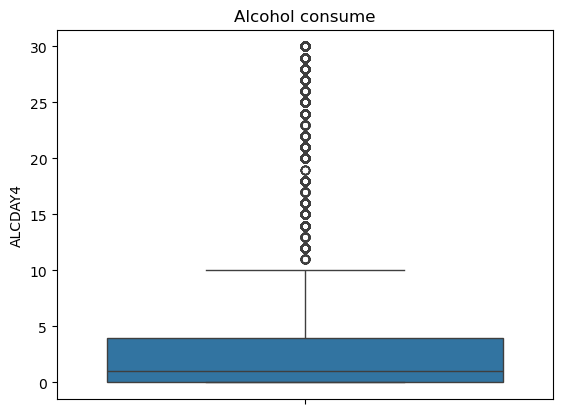

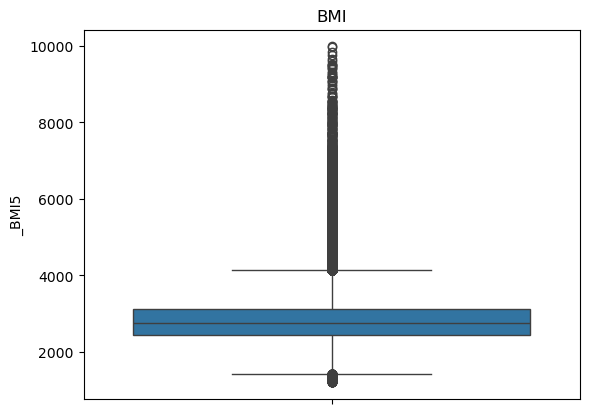

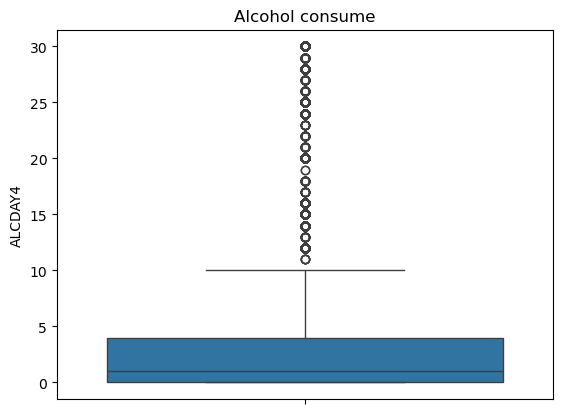

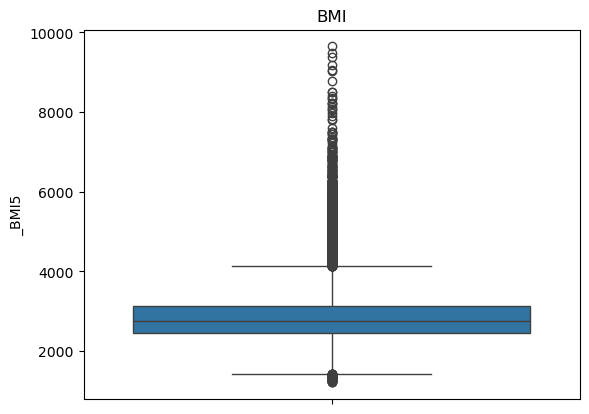

In [14]:
#Check for outliers in continuos variables (ALCDAY4, _BMI5)

sns.boxplot(X_train['ALCDAY4'])
plt.title('Alcohol consume')
plt.show()

sns.boxplot((X_train['_BMI5']))
plt.title('BMI')
plt.show()

sns.boxplot(X_test['ALCDAY4'])
plt.title('Alcohol consume')
plt.show()

sns.boxplot((X_test['_BMI5']))
plt.title('BMI')
plt.show()

In [15]:
print(X_train.apply(lambda x: x.min()))
print(X_train.apply(lambda x: x.max()))
print(X_test.apply(lambda x: x.min()))
print(X_test.apply(lambda x: x.max()))

_AGE80        18.0
_SEX           0.0
EDUCA          1.0
INCOME3        1.0
EXERANY2       0.0
_SMOKER3       1.0
ALCDAY4        0.0
_BMI5       1200.0
EMPLOY1        1.0
PHYSHLTH       0.0
CVDINFR4       0.0
CVDCRHD4       0.0
SDHFOOD1       1.0
dtype: float64
_AGE80        80.0
_SEX           1.0
EDUCA          6.0
INCOME3       11.0
EXERANY2       1.0
_SMOKER3       4.0
ALCDAY4       30.0
_BMI5       9984.0
EMPLOY1        8.0
PHYSHLTH      30.0
CVDINFR4       1.0
CVDCRHD4       1.0
SDHFOOD1       5.0
dtype: float64
_AGE80        18.0
_SEX           0.0
EDUCA          1.0
INCOME3        1.0
EXERANY2       0.0
_SMOKER3       1.0
ALCDAY4        0.0
_BMI5       1211.0
EMPLOY1        1.0
PHYSHLTH       0.0
CVDINFR4       0.0
CVDCRHD4       0.0
SDHFOOD1       1.0
dtype: float64
_AGE80        80.0
_SEX           1.0
EDUCA          6.0
INCOME3       11.0
EXERANY2       1.0
_SMOKER3       4.0
ALCDAY4       30.0
_BMI5       9652.0
EMPLOY1        8.0
PHYSHLTH      30.0
CVDINFR4       1.0
CVDCR

In [27]:
def pre_model(data=pd.DataFrame()):
    preprocessed = data

    preprocessed['_SEX'] = preprocessed['_SEX'].astype('int').astype('category')
    preprocessed['EXERANY2'] = preprocessed['EXERANY2'].astype('int').astype('category')
    preprocessed['_SMOKER3'] = preprocessed['_SMOKER3'].astype('int').astype('category')
    preprocessed['EMPLOY1'] = preprocessed['EMPLOY1'].astype('int').astype('category')
    preprocessed['CVDINFR4'] = preprocessed['CVDINFR4'].astype('int').astype('category')
    preprocessed['CVDCRHD4'] = preprocessed['CVDCRHD4'].astype('int').astype('category')
    
    return preprocessed
pass

In [29]:
X_train = pre_model(X_train)
X_test = pre_model(X_test)

y_train = y_train.astype('int').astype('category')
y_test = y_test.astype('int').astype('category')


In [ ]:
X_train.dtypes

In [18]:
# EVALUATION FUNCTION

def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)

    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
        print("ROC AUC:", roc_auc_score(y_test, y_score))
        RocCurveDisplay.from_predictions(y_test, y_score)
pass

In [19]:
#base model
base_model = DecisionTreeClassifier(random_state=42, max_depth=4)
base_model.fit(X_train,y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


              precision    recall  f1-score   support

         0.0       0.86      0.99      0.92     78307
         1.0       0.51      0.06      0.10     13021

    accuracy                           0.86     91328
   macro avg       0.68      0.52      0.51     91328
weighted avg       0.81      0.86      0.81     91328

[[77570   737]
 [12266   755]]
ROC AUC: 0.7424465530571144


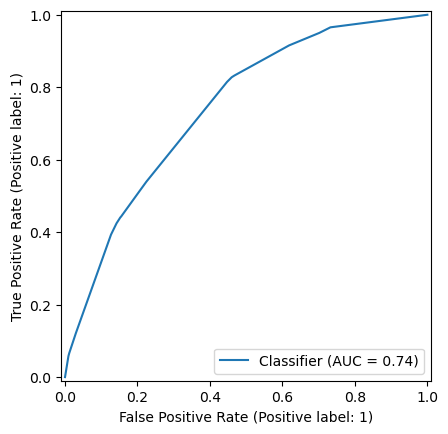

In [20]:
evaluate(base_model, X_test=X_test, y_test=y_test)

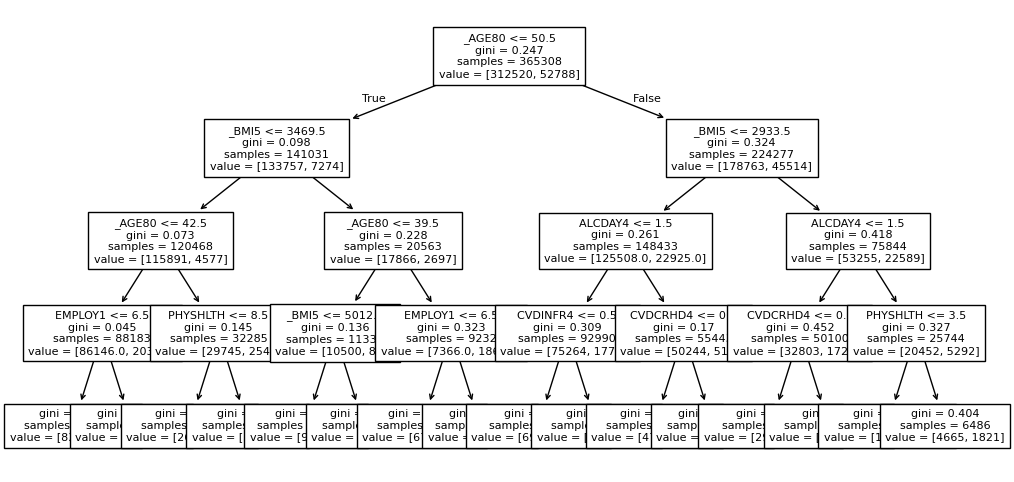

In [21]:
plt.figure(figsize=(12,6))  # set plot size (denoted in inches)
plot_tree(base_model, fontsize=8, max_depth=4, feature_names=X_train.columns)
plt.show()

In [22]:
#second model
model_2 = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )
model_2.fit(X_train,y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


              precision    recall  f1-score   support

         0.0       0.87      0.97      0.92     78307
         1.0       0.42      0.12      0.19     13021

    accuracy                           0.85     91328
   macro avg       0.64      0.55      0.55     91328
weighted avg       0.81      0.85      0.81     91328

[[76095  2212]
 [11420  1601]]
ROC AUC: 0.7536692974543088


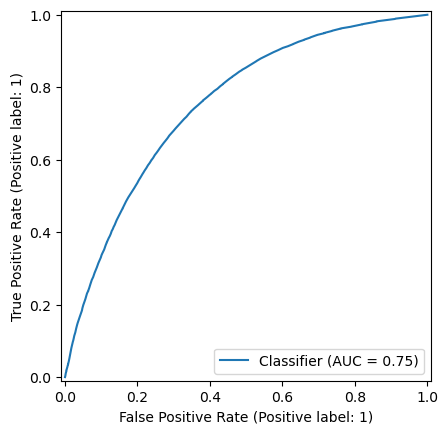

In [23]:
#evaluate
evaluate(model=model_2, X_test=X_test, y_test=y_test)

In [30]:
#third model
model_3 = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        enable_categorical = True
    )
model_3.fit(X_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


              precision    recall  f1-score   support

           0       0.87      0.99      0.92     78307
           1       0.55      0.08      0.15     13021

    accuracy                           0.86     91328
   macro avg       0.71      0.54      0.53     91328
weighted avg       0.82      0.86      0.81     91328

[[77429   878]
 [11927  1094]]
ROC AUC: 0.7895900425674394


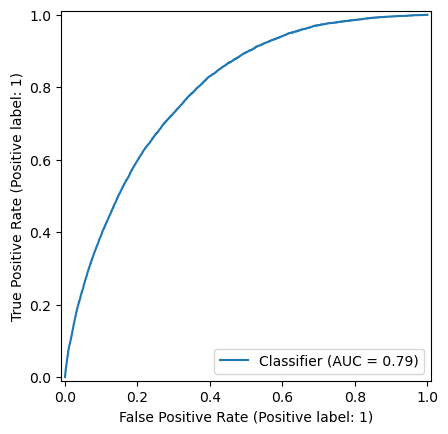

In [31]:
#evaluate

evaluate(model=model_3, X_test=X_test, y_test=y_test)

In [32]:
# unified dataset

y_train = pd.Series(y_train, name='Target', index=X_train.index)
y_test = pd.Series(y_test, name='Target', index=X_test.index)

train_df = pd.concat([X_train, y_train], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)

full_df = pd.concat([train_df, test_df], axis=0)

full_df.to_csv('cleaned_dataset.csv')